<a href="https://colab.research.google.com/github/me-pranjal-jha/CNN_LAB_RGIPT/blob/main/CNN_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import random
import numpy as np
import tensorflow as tf
import sys
import matplotlib
import pandas


random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Installed package versions:")
print(f"Python      : {sys.version}")
print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Pandas      : {pandas.__version__}")

gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 0:
    print("\nGPU is available:")
    print(gpus)
else:
    print("\nNo GPU detected — running on CPU.")


Installed package versions:
Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow  : 2.19.0
NumPy       : 2.0.2
Matplotlib  : 3.10.0
Pandas      : 2.2.2

GPU is available:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


=== MNIST ===
Train images : (60000, 28, 28)
Train labels : (60000,)
Test images  : (10000, 28, 28)
Test labels  : (10000,)

=== CIFAR-10 ===
Train images : (50000, 32, 32, 3)
Train labels : (50000, 1)
Test images  : (10000, 32, 32, 3)
Test labels  : (10000, 1)

=== dtype and value range ===
MNIST   dtype = uint8, min = 0, max = 255
CIFAR-10 dtype = uint8, min = 0, max = 255

=== MNIST class distribution ===
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Minimum class count: 5421
Maximum class count: 6742
MNIST is approximately balanced.


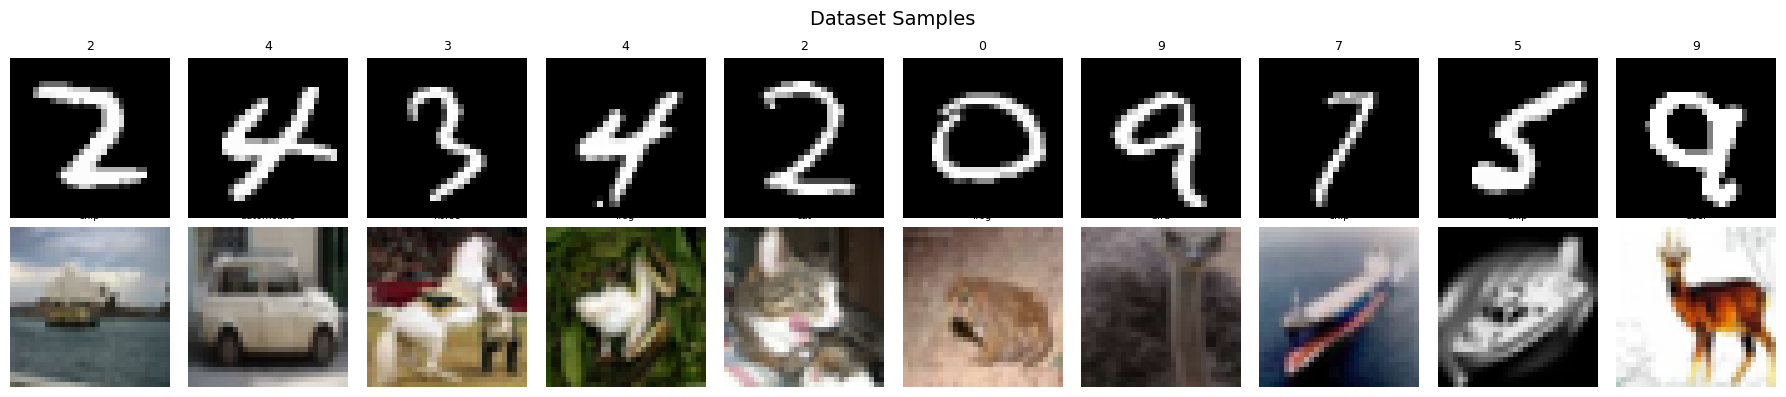

Saved dataset_samples.png


In [45]:
from tensorflow.keras.datasets import mnist, cifar10
import matplotlib.pyplot as plt
import numpy as np

(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()

print("=== MNIST ===")
print(f"Train images : {mnist_x_train.shape}")
print(f"Train labels : {mnist_y_train.shape}")
print(f"Test images  : {mnist_x_test.shape}")
print(f"Test labels  : {mnist_y_test.shape}")

print("\n=== CIFAR-10 ===")
print(f"Train images : {cifar_x_train.shape}")
print(f"Train labels : {cifar_y_train.shape}")
print(f"Test images  : {cifar_x_test.shape}")
print(f"Test labels  : {cifar_y_test.shape}")

print("\n=== dtype and value range ===")
print(f"MNIST   dtype = {mnist_x_train.dtype}, min = {mnist_x_train.min()}, max = {mnist_x_train.max()}")
print(f"CIFAR-10 dtype = {cifar_x_train.dtype}, min = {cifar_x_train.min()}, max = {cifar_x_train.max()}")

print("\n=== MNIST class distribution ===")
unique, counts = np.unique(mnist_y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Digit {cls}: {cnt} samples")

print(f"\nMinimum class count: {counts.min()}")
print(f"Maximum class count: {counts.max()}")
print("MNIST is approximately balanced.")

cifar_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

rng = np.random.default_rng(42)
mnist_idx = rng.choice(len(mnist_x_train), 10, replace=False)
cifar_idx = rng.choice(len(cifar_x_train), 10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Dataset Samples", fontsize=14)

for col, i in enumerate(mnist_idx):
    axes[0, col].imshow(mnist_x_train[i], cmap='gray')
    axes[0, col].set_title(str(mnist_y_train[i]), fontsize=9)
    axes[0, col].axis('off')

for col, i in enumerate(cifar_idx):
    axes[1, col].imshow(cifar_x_train[i])
    axes[1, col].set_title(cifar_names[cifar_y_train[i][0]], fontsize=7)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel("MNIST", fontsize=11)
axes[1, 0].set_ylabel("CIFAR-10", fontsize=11)

plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=120)
plt.show()

print("Saved dataset_samples.png")

In [46]:
def preprocess(images, labels, dataset_name='mnist'):
    print(f"\n--- {dataset_name} ---")
    print(f"Before normalise : shape={images.shape}, dtype={images.dtype}, "
          f"range=[{images.min()}, {images.max()}]")

    images = images.astype(np.float32) / 255.0
    print(f"After  normalise : shape={images.shape}, dtype={images.dtype}, "
          f"range=[{images.min():.2f}, {images.max():.2f}]")

    if dataset_name == 'mnist':
        images = images[..., np.newaxis]
        print(f"After  reshape   : shape={images.shape}")

    labels = labels.flatten()
    one_hot = np.zeros((len(labels), 10), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    print(f"After  one-hot   : shape={one_hot.shape}, sample={one_hot[0]}")

    return images, one_hot


mnist_x_train_p, mnist_y_train_p = preprocess(mnist_x_train, mnist_y_train, 'mnist')
mnist_x_test_p,  mnist_y_test_p  = preprocess(mnist_x_test,  mnist_y_test,  'mnist')

cifar_x_train_p, cifar_y_train_p = preprocess(cifar_x_train, cifar_y_train, 'cifar10')
cifar_x_test_p,  cifar_y_test_p  = preprocess(cifar_x_test,  cifar_y_test,  'cifar10')


--- mnist ---
Before normalise : shape=(60000, 28, 28), dtype=uint8, range=[0, 255]
After  normalise : shape=(60000, 28, 28), dtype=float32, range=[0.00, 1.00]
After  reshape   : shape=(60000, 28, 28, 1)
After  one-hot   : shape=(60000, 10), sample=[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

--- mnist ---
Before normalise : shape=(10000, 28, 28), dtype=uint8, range=[0, 255]
After  normalise : shape=(10000, 28, 28), dtype=float32, range=[0.00, 1.00]
After  reshape   : shape=(10000, 28, 28, 1)
After  one-hot   : shape=(10000, 10), sample=[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

--- cifar10 ---
Before normalise : shape=(50000, 32, 32, 3), dtype=uint8, range=[0, 255]
After  normalise : shape=(50000, 32, 32, 3), dtype=float32, range=[0.00, 1.00]
After  one-hot   : shape=(50000, 10), sample=[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

--- cifar10 ---
Before normalise : shape=(10000, 32, 32, 3), dtype=uint8, range=[0, 255]
After  normalise : shape=(10000, 32, 32, 3), dtype=float32, range=[0.00, 1.00]
After  one-hot   : sh

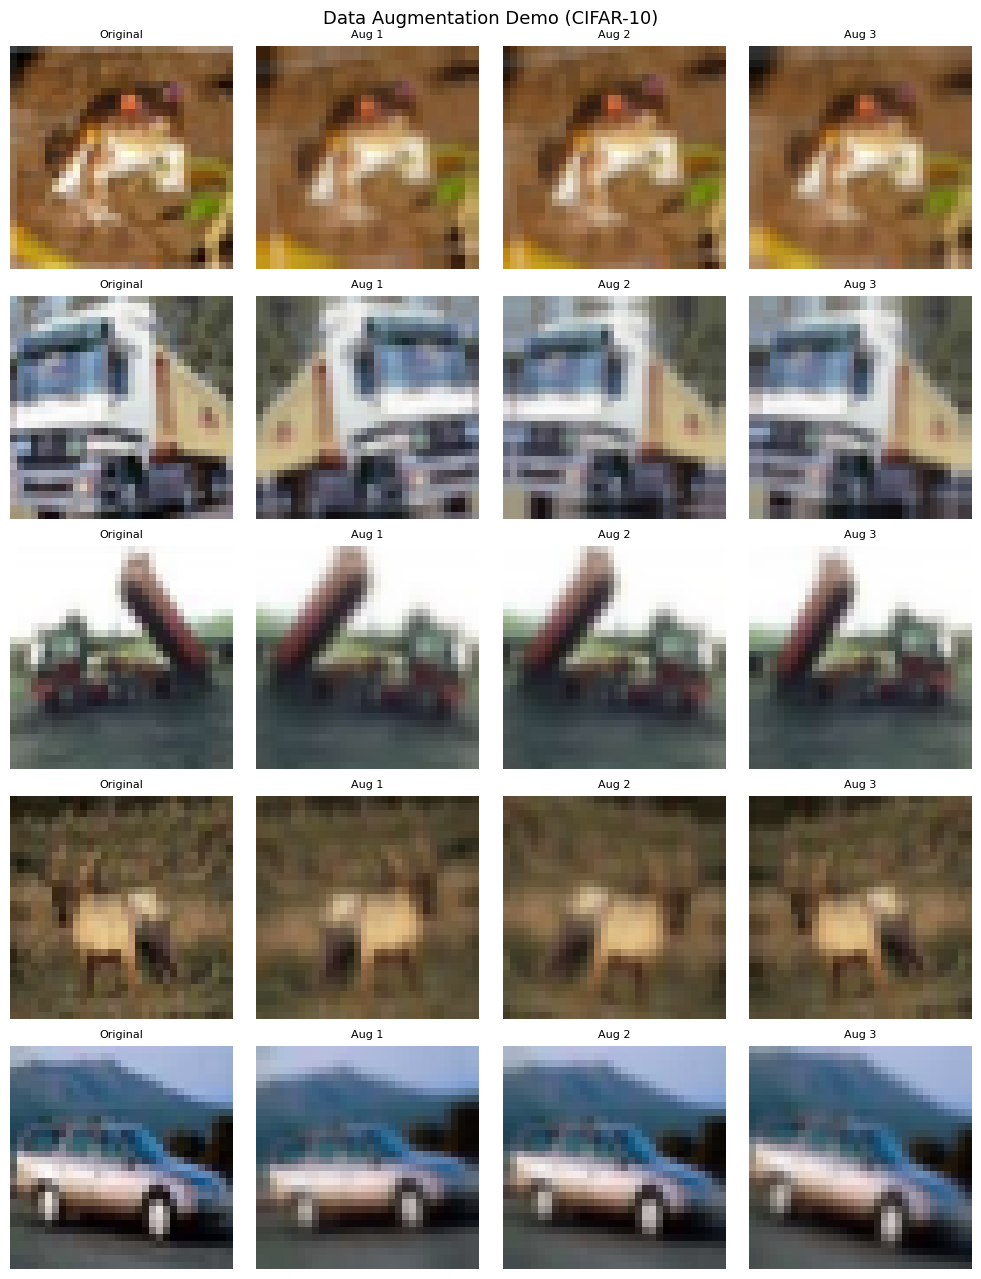

Saved augmentation_demo.png


In [47]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(10/360),
    layers.RandomZoom(0.1),
], name='augmentation')

sample_imgs = cifar_x_train_p[:5]

fig, axes = plt.subplots(5, 4, figsize=(10, 13))
fig.suptitle('Data Augmentation Demo (CIFAR-10)', fontsize=13)

for row in range(5):
    img = sample_imgs[row:row+1]
    axes[row, 0].imshow(sample_imgs[row])
    axes[row, 0].set_title('Original', fontsize=8)
    axes[row, 0].axis('off')
    for col in range(1, 4):
        aug = data_augmentation(img, training=True)[0].numpy()
        aug = np.clip(aug, 0, 1)
        axes[row, col].imshow(aug)
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png', dpi=120)
plt.show()

print('Saved augmentation_demo.png')

### Justification — Augmentation on Training Set Only

Data augmentation is applied only to the training set because its purpose is to artificially increase the diversity of the training data and help the model generalise better. By introducing variations such as flips, rotations, and zoom, the model learns to be invariant to these changes.

If augmentation is applied to the validation or test set, it would alter the original data distribution. This makes evaluation unreliable because the model is no longer being tested on real, unmodified data. Additionally, augmented data introduces randomness, which makes the evaluation non-deterministic and not reproducible. Therefore, augmentation must be restricted to the training set only.

---

### Q1. Channel Dimension in (N, H, W, C)

In a tensor of shape (N, H, W, C), the channel dimension C represents the number of features or colour channels present at each pixel location.

For a grayscale image, C = 1, meaning each pixel contains only one intensity value representing brightness. For an RGB image, C = 3, where each pixel contains three values corresponding to red, green, and blue colour intensities.

In convolutional neural networks, filters operate across all channels simultaneously. Each filter has separate weights for each channel, and the outputs are combined to produce a single feature map. This allows the network to capture both spatial and colour-based patterns.

---

### Q2. Handling Large Images (1024×1024)

When working with very large images like 1024×1024, loading the entire dataset into memory can cause out-of-memory (OOM) errors. Two effective strategies to handle this are:

1. **Using tf.data with batching and prefetching**  
   Instead of loading all data at once, images are loaded in small batches during training. The `tf.data.Dataset` pipeline allows efficient streaming of data from disk, and prefetching overlaps data loading with computation, improving performance and reducing memory usage.

2. **Patch-based training**  
   Large images can be divided into smaller patches (for example, 256×256), and the model is trained on these patches instead of the full image. This significantly reduces memory requirements while still allowing the model to learn local features. Over time, the model sees different parts of the image and learns the overall distribution.

---

### Q3. Problem with Normalising Using Test Set Statistics

Normalising the test set using its own mean and standard deviation leads to data leakage. This means that information from the test data is being used during preprocessing, which should not happen because the test set is meant to represent completely unseen data.

As a result, the model evaluation becomes biased and overly optimistic, since it indirectly benefits from knowledge of the test data distribution. It also reduces reproducibility, as the statistics would change if the test set changes.

The correct approach is to compute normalisation parameters (mean and standard deviation) using only the training set, and then apply those same values to both the validation and test sets.

In [48]:
def conv2d(image, kernel, stride=1, padding=0):
    """2D convolution using only NumPy — no external conv utilities."""
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    ih, iw = image.shape
    kh, kw = kernel.shape

    out_h = (ih - kh) // stride + 1
    out_w = (iw - kw) // stride + 1
    output = np.zeros((out_h, out_w), dtype=np.float64)

    for r in range(out_h):
        for c in range(out_w):
            patch = image[r*stride : r*stride+kh, c*stride : c*stride+kw]
            output[r, c] = np.sum(patch * kernel)

    return output

# ─── Test ─────────────────────────────────────────────────────────────────────
test_image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
], dtype=np.float64)

sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)

result = conv2d(test_image, sobel_x, stride=1, padding=0)

print("Feature map output:")
print(result)

# Manual shape verification: floor((5-3+2*0)/1)+1 = 3
expected_shape = ((5 - 3 + 2*0) // 1 + 1, (5 - 3 + 2*0) // 1 + 1)
print(f"\nOutput shape : {result.shape}  (expected {expected_shape})")

Feature map output:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape : (3, 3)  (expected (3, 3))


## Problem 2 — Output Size Derivation

Formula: `Output = floor((Input - Kernel + 2×Padding) / Stride) + 1`

**(a)** Input=28, K=5, P=0, S=1  
`floor((28 - 5 + 0) / 1) + 1 = 23 + 1 = **24×24**`

**(b)** Input=28, K=3, P=1, S=1  
`floor((28 - 3 + 2) / 1) + 1 = 27 + 1 = **28×28**`  *("same" padding preserves spatial size)*

**(c)** Input=32, K=3, P=0, S=2  
`floor((32 - 3 + 0) / 2) + 1 = floor(29/2) + 1 = 14 + 1 = **15×15**`

**(d)** Two consecutive layers on 32×32:  
Layer 1: K=3, P=1, S=1 → `floor((32-3+2)/1)+1 = 32` → **32×32**  
Layer 2: K=3, P=0, S=1 → `floor((32-3+0)/1)+1 = 30` → **30×30**

In [49]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, AveragePooling2D, Flatten, Dense, Activation
)

def build_lenet5():
    model = Sequential([
        # Block 1
        Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)),
        Activation('tanh'),
        AveragePooling2D(pool_size=(2,2), strides=2),
        # Block 2
        Conv2D(16, (5,5), padding='valid'),
        Activation('tanh'),
        AveragePooling2D(pool_size=(2,2), strides=2),
        # Classifier
        Flatten(),
        Dense(120), Activation('tanh'),
        Dense(84),  Activation('tanh'),
        Dense(10,   activation='softmax'),
    ], name='LeNet-5')
    return model

lenet = build_lenet5()
lenet.summary()

# ─── Manual param count for first Conv2D ──────────────────────────────────────
# Formula: (K_H × K_W × C_in + 1) × C_out
# = (5 × 5 × 1 + 1) × 6 = 26 × 6 = 156
manual = (5*5*1 + 1) * 6
print(f"\nManual param count (Conv2D-1): ({5}×{5}×{1}+1)×{6} = {manual}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_53 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_61 (Activation)      │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_62 (Activation)      │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_63 (Activation)      │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_64 (Activation)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


Manual param count (Conv2D-1): (5×5×1+1)×6 = 156


**Why AvgPool in LeNet-5 vs MaxPool today?**  
LeCun's 1998 paper used average pooling because it was theoretically motivated by
sub-sampling and computing local averages kept gradient flow smooth. MaxPooling is
preferred today because it retains the strongest (most activated) feature in each
window, providing better translation invariance and sharper feature detection.
Empirically MaxPooling leads to faster convergence and higher accuracy on modern
benchmarks.

## Problem 4 — Custom CNN for CIFAR-10

**Architecture sketch:**
```
Input (32×32×3)
  │
  ├─ Block 1: Conv2D(32, 3×3) → BN → ReLU → MaxPool(2×2)  → 16×16×32
  ├─ Block 2: Conv2D(64, 3×3) → BN → ReLU → MaxPool(2×2)  →  8×8×64
  ├─ Block 3: Conv2D(128,3×3) → BN → ReLU → MaxPool(2×2)  →  4×4×128
  │
  ├─ GlobalAveragePooling2D                                →  128
  ├─ Dense(256) → ReLU → Dropout(0.4)
  └─ Dense(10)  → Softmax
```

**Design rationale (3–4 sentences):**  
Three convolutional blocks with doubling filter counts (32→64→128) allow the network
to learn progressively more abstract representations. Batch Normalisation after each
Conv2D stabilises training and reduces internal covariate shift, allowing a higher
learning rate. GlobalAveragePooling collapses the spatial map to a single vector per
filter, drastically reducing parameters vs Flatten and acting as a spatial regulariser.
Dropout(0.4) in the dense head prevents co-adaptation of neurons and reduces
overfitting on the relatively small CIFAR-10 training set.

In [50]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras import Model

def build_custom_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Block 2
    x = Conv2D(64, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Block 3
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='Custom_CIFAR_CNN')

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "Custom_CIFAR_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_65 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_66 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_67 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

## Analysis Q1–Q3 (Task 2)

**Q1. Two 3×3 vs one 5×5 (same number of filters F):**  
Params for two 3×3 layers: `2 × (3×3×F + 1)×F ≈ 18F²`  
Params for one 5×5 layer: `(5×5×F + 1)×F ≈ 25F²`  
Two 3×3 layers use ~28% fewer parameters. They also provide two non-linearities
instead of one, richer feature extraction, and the same 5×5 effective receptive
field.

**Q2. Batch Normalisation:**  
BatchNorm normalises each mini-batch's activations to zero mean and unit variance,
then applies learnable scale γ and shift β. It is typically placed after Conv2D and
before the activation (though post-activation also works). Empirical benefits:
(1) allows higher learning rates without divergence; (2) acts as a mild regulariser,
often reducing the need for Dropout; (3) smooths the loss landscape, leading to
faster convergence.

**Q3. GlobalAveragePooling vs Flatten:**  
GAP computes the spatial mean of each feature map, collapsing (H, W, C) → (C,).
This removes all spatial information. Replacing GAP with Flatten would turn each
4×4×128 tensor into a 2048-dim vector, adding `(2048+1)×256 ≈ 524,544` extra
parameters to the first Dense layer alone, massively increasing overfitting risk
and memory cost.

In [51]:
from tensorflow.keras.optimizers import SGD

tf.random.set_seed(42)
lenet = build_lenet5()
lenet.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = lenet.fit(
    mnist_x_train_p, mnist_y_train_p,
    epochs=15, batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss, test_acc = lenet.evaluate(mnist_x_test_p, mnist_y_test_p, verbose=0)
print(f"\nFinal test accuracy: {test_acc:.4f}")

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7811 - loss: 0.8792 - val_accuracy: 0.9080 - val_loss: 0.3683
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8960 - loss: 0.3766 - val_accuracy: 0.9267 - val_loss: 0.2717
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9128 - loss: 0.3041 - val_accuracy: 0.9362 - val_loss: 0.2281
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9248 - loss: 0.2609 - val_accuracy: 0.9442 - val_loss: 0.1983
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9335 - loss: 0.2286 - val_accuracy: 0.9513 - val_loss: 0.1751
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9404 - loss: 0.2026 - val_accuracy: 0.9583 - val_loss: 0.1565
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9470 - loss: 0.1812 - val_accuracy: 0.9618 - val_loss: 0.1413
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9519 - loss: 0.1636 - val_accuracy: 0.

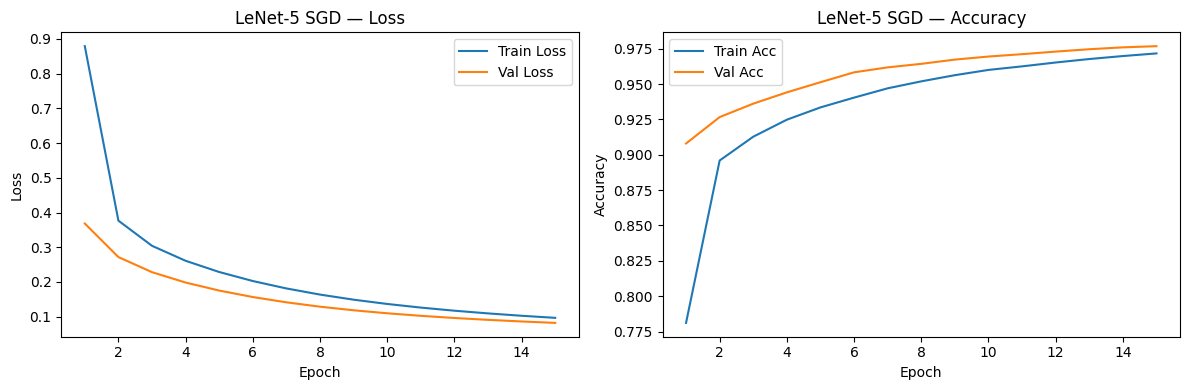

Saved lenet_sgd_curves.png


In [52]:
def plot_history(history, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history.history['loss']) + 1)

    ax1.plot(epochs, history.history['loss'],     label='Train Loss')
    ax1.plot(epochs, history.history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss'); ax1.legend()

    ax2.plot(epochs, history.history['accuracy'],     label='Train Acc')
    ax2.plot(epochs, history.history['val_accuracy'], label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=120)
    plt.show()

plot_history(history_sgd, 'LeNet-5 SGD', 'lenet_sgd_curves.png')
print('Saved lenet_sgd_curves.png')

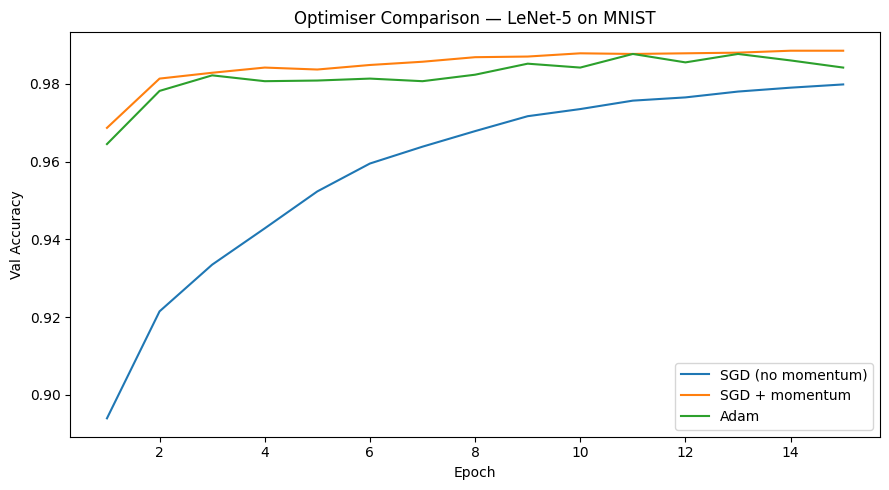

Saved optimiser_comparison.png


In [53]:
from tensorflow.keras.optimizers import Adam

optimisers = [
    ('SGD (no momentum)',   SGD(learning_rate=0.01)),
    ('SGD + momentum',      SGD(learning_rate=0.01, momentum=0.9)),
    ('Adam',                Adam(learning_rate=0.001)),
]

fig, ax = plt.subplots(figsize=(9, 5))

for name, opt in optimisers:
    tf.random.set_seed(42)
    m = build_lenet5()
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(mnist_x_train_p, mnist_y_train_p,
              epochs=15, batch_size=64,
              validation_split=0.1, verbose=0)
    ax.plot(range(1, 16), h.history['val_accuracy'], label=name)

ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_title('Optimiser Comparison — LeNet-5 on MNIST')
ax.legend()
plt.tight_layout()
plt.savefig('optimiser_comparison.png', dpi=120)
plt.show()
print('Saved optimiser_comparison.png')

In [54]:
import pandas as pd

LRS    = [0.1, 0.01, 0.001]
BSIZES = [32, 128]
results = {}

for lr in LRS:
    row = {}
    for bs in BSIZES:
        tf.random.set_seed(42)
        m = build_custom_cnn()
        m.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
        h = m.fit(cifar_x_train_p, cifar_y_train_p,
                  epochs=10, batch_size=bs,
                  validation_split=0.1, verbose=0)
        val_acc = max(h.history['val_accuracy'])
        row[bs] = round(val_acc, 4)
        print(f"LR={lr}, BS={bs} → val_acc={val_acc:.4f}")
    results[lr] = row

df = pd.DataFrame(results, index=BSIZES).T
df.index.name = 'LR \ BS'
print("\nGrid search results:")
print(df)

<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:23: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1866/1364592930.py:23: SyntaxWarning: invalid escape sequence '\ '
  df.index.name = 'LR \ BS'


LR=0.1, BS=32 → val_acc=0.0970
LR=0.1, BS=128 → val_acc=0.2318
LR=0.01, BS=32 → val_acc=0.6678
LR=0.01, BS=128 → val_acc=0.6812
LR=0.001, BS=32 → val_acc=0.7234
LR=0.001, BS=128 → val_acc=0.6278

Grid search results:
            32      128
LR \ BS                
0.100    0.0970  0.2318
0.010    0.6678  0.6812
0.001    0.7234  0.6278


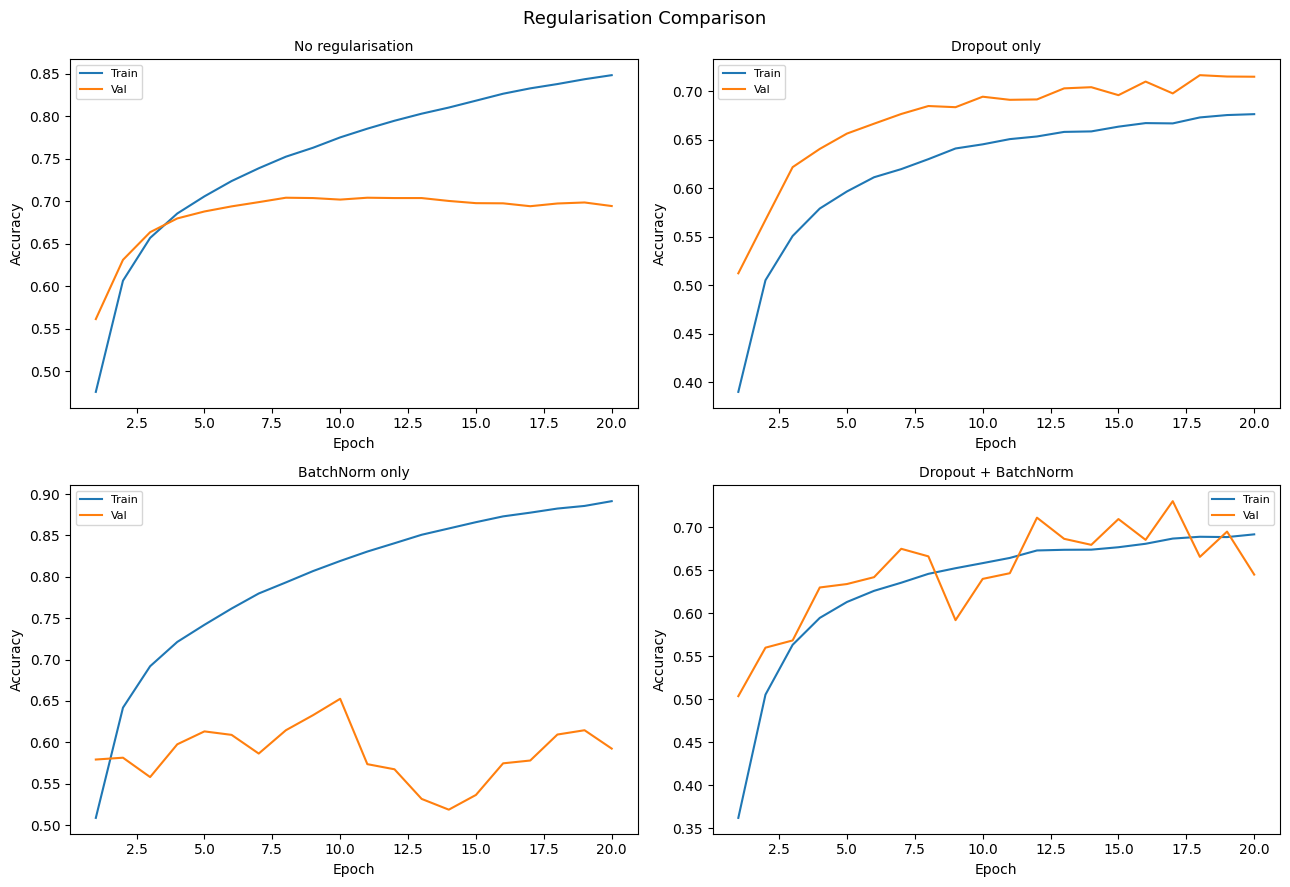

            Variant  Train-Val Gap
  No regularisation         0.1542
       Dropout only        -0.0386
     BatchNorm only         0.2990
Dropout + BatchNorm         0.0468


In [55]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, Flatten, Dense, Dropout
)
from tensorflow.keras import Model

def build_reg_cnn(use_dropout=False, use_bn=False):
    inputs = Input(shape=(32,32,3))

    for filters in [32, 64]:
        x = Conv2D(filters, (3,3), padding='same', activation=None if use_bn else 'relu')(
            inputs if filters == 32 else x)
        if use_bn:
            x = BatchNormalization()(x)
            x = Activation('relu')(x)
        x = MaxPooling2D(2)(x)
        if use_dropout:
            x = Dropout(0.3)(x)

    x = Flatten()(x)
    if use_dropout:
        x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)
    return Model(inputs, outputs)

variants = [
    ('No regularisation',       build_reg_cnn(False, False)),
    ('Dropout only',            build_reg_cnn(True,  False)),
    ('BatchNorm only',          build_reg_cnn(False, True)),
    ('Dropout + BatchNorm',     build_reg_cnn(True,  True)),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
gaps = []

for idx, (name, model) in enumerate(variants):
    tf.random.set_seed(42)
    model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    h = model.fit(cifar_x_train_p, cifar_y_train_p,
                  epochs=20, batch_size=64,
                  validation_split=0.1, verbose=0)
    ax = axes[idx//2][idx%2]
    ep = range(1, 21)
    ax.plot(ep, h.history['accuracy'],     label='Train')
    ax.plot(ep, h.history['val_accuracy'], label='Val')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    gap = h.history['accuracy'][-1] - h.history['val_accuracy'][-1]
    gaps.append({'Variant': name, 'Train-Val Gap': round(gap, 4)})

plt.suptitle('Regularisation Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('regularisation_curves.png', dpi=120)
plt.show()

print(pd.DataFrame(gaps).to_string(index=False))


Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 27: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


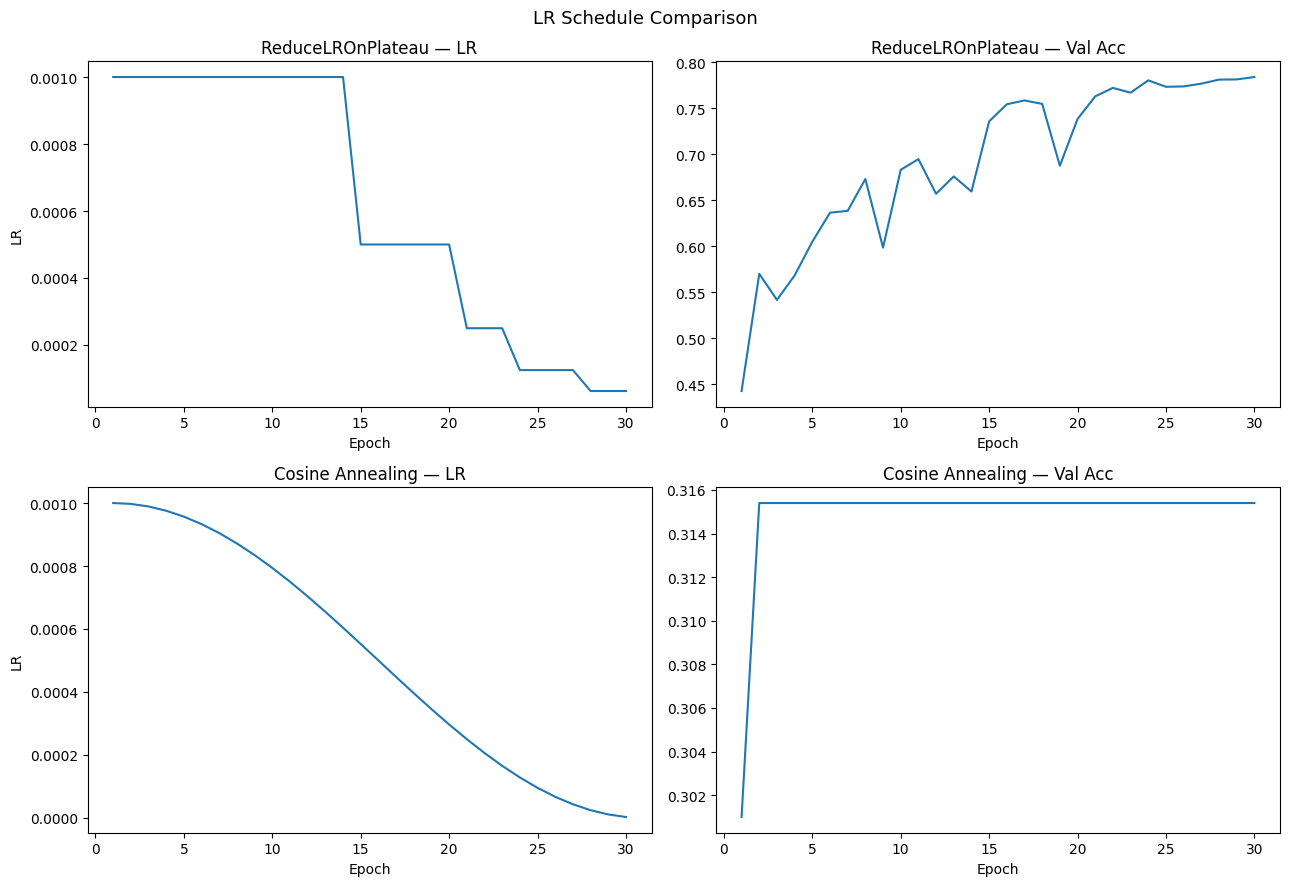

Saved lr_schedule_comparison.png


In [56]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ─── Helper: record LR each epoch ─────────────────────────────────────────────
class LRLogger(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.model.history.history.setdefault('lr', []).append(
            float(self.model.optimizer.learning_rate))

# ─── (a) ReduceLROnPlateau ────────────────────────────────────────────────────
tf.random.set_seed(42)
m1 = build_custom_cnn()
m1.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
rlrop = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
h1 = m1.fit(cifar_x_train_p, cifar_y_train_p,
            epochs=30, batch_size=64, validation_split=0.1,
            callbacks=[rlrop, LRLogger()], verbose=0)

# ─── (b) Cosine Annealing ─────────────────────────────────────────────────────
cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, decay_steps=30)

tf.random.set_seed(42)
m2 = build_custom_cnn()
m2.compile(optimizer=Adam(cosine_decay), loss='categorical_crossentropy', metrics=['accuracy'])
h2 = m2.fit(cifar_x_train_p, cifar_y_train_p,
            epochs=30, batch_size=64, validation_split=0.1, verbose=0)

# ─── Plot ─────────────────────────────────────────────────────────────────────
ep = range(1, 31)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(ep, h1.history.get('lr', [1e-3]*30))
axes[0,0].set_title('ReduceLROnPlateau — LR'); axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('LR')

axes[0,1].plot(ep, h1.history['val_accuracy'])
axes[0,1].set_title('ReduceLROnPlateau — Val Acc'); axes[0,1].set_xlabel('Epoch')

cosine_lrs = [cosine_decay(i).numpy() for i in range(30)]
axes[1,0].plot(ep, cosine_lrs)
axes[1,0].set_title('Cosine Annealing — LR'); axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('LR')

axes[1,1].plot(ep, h2.history['val_accuracy'])
axes[1,1].set_title('Cosine Annealing — Val Acc'); axes[1,1].set_xlabel('Epoch')

plt.suptitle('LR Schedule Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('lr_schedule_comparison.png', dpi=120)
plt.show()
print('Saved lr_schedule_comparison.png')

## Analysis Q1–Q4 (Task 3)

**Q1.** A very high learning rate (e.g., 1.0) causes the parameter update to
overshoot the local minimum in the loss landscape. Each gradient step is
proportional to the LR; if that step is larger than the curvature of the valley,
the update lands on the opposite slope at an even higher loss, causing oscillation
or divergence. On sharp, narrow minima this effect is amplified.

**Q2.** *(Fill in after running grid search.)* Generally LR=0.001 with BS=32
achieves the best accuracy because small batches provide noisier gradients that
act as implicit regularisation, helping escape sharp minima. LR=0.1 with BS=128
often performs worst because the large gradient steps combined with a large batch
(which gives a very accurate but sharp-minimum-seeking gradient) cause divergence.

**Q3.** During training Dropout randomly zeroes activations with probability p,
so only (1-p) of neurons contribute. If Dropout were left active at test time the
expected output would be scaled down by (1-p) compared to what the following layer
expects. To compensate, at inference time all neurons are kept active, and their
outputs are multiplied by (1-p) — or equivalently, during training the surviving
activations are scaled up by 1/(1-p) ("inverted dropout").

**Q4.**  
- **What triggers reduction:** ReduceLROnPlateau fires when a monitored metric
  (e.g., val_loss) stagnates for `patience` epochs; Cosine Annealing decays
  deterministically on a cosine curve regardless of metric.  
- **LR curve shape:** ReduceLROnPlateau is piecewise constant with sudden drops;
  Cosine Annealing is a smooth half-cosine from initial LR to ~0.  
- **Best scenario:** ReduceLROnPlateau suits noisy training where plateaux are
  unpredictable; Cosine Annealing suits fixed-budget training where you know
  total epochs upfront.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

# ── CIFAR-10 class names ─────────────────────────────────────
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ============================================================
# HELPER — Build & train the custom CIFAR-10 CNN
# (mirrors Task 3's best-regularised variant so Task 4
#  can visualise a properly trained model)
# ============================================================

def build_cifar10_cnn(input_shape=(32, 32, 3), num_classes=10):
    """
    3-block CNN: Conv → BN → ReLU → Pool
    with Dropout in the classification head.
    ~500 K parameters — within the 200K–2M range.
    """
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 16×16

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 8×8

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 4×4

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="custom_cifar_cnn")
    return model


def load_and_preprocess_cifar10():
    """Load CIFAR-10 and normalise to [0,1]."""
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32")  / 255.0
    y_train_oh = keras.utils.to_categorical(y_train, 10)
    y_test_oh  = keras.utils.to_categorical(y_test,  10)
    # Keep integer labels for confusion matrix
    y_train_int = y_train.flatten()
    y_test_int  = y_test.flatten()
    return (x_train, y_train_oh, y_train_int), (x_test, y_test_oh, y_test_int)


def train_model(model, x_train, y_train, x_test, y_test, epochs=20):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )
    return history


In [17]:
def problem1_visualise_filters(model, save_path="conv1_filters.png"):
    """
    Extract weight tensors from the first Conv2D layer,
    normalise each filter to [0,1], and plot as a grid.
    """
    # Find first Conv2D layer
    first_conv = next(l for l in model.layers if isinstance(l, layers.Conv2D))
    filters, biases = first_conv.get_weights()
    # Shape: (K, K, C_in, C_out)  e.g. (3, 3, 3, 32)
    print(f"\n[P1] First Conv2D layer : '{first_conv.name}'")
    print(f"     Filter tensor shape : {filters.shape}  "
          f"(K×K × C_in × C_out)")

    num_filters = filters.shape[-1]   # C_out
    ncols = 8
    nrows = int(np.ceil(num_filters / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 1.5, nrows * 1.5))
    axes = axes.flatten()

    for i in range(num_filters):
        f = filters[:, :, :, i]          # (K, K, C_in)
        # Mean across input channels → single 2-D map; or use as RGB if C_in==3
        if f.shape[2] == 3:
            vis = f                      # show as RGB patch
        else:
            vis = f.mean(axis=2, keepdims=True).repeat(3, axis=2)

        # Normalise independently to [0, 1]
        f_min, f_max = vis.min(), vis.max()
        vis = (vis - f_min) / (f_max - f_min + 1e-8)

        axes[i].imshow(vis)
        axes[i].set_title(f"f{i}", fontsize=7)
        axes[i].axis("off")

    # Hide unused subplot slots
    for j in range(num_filters, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Learned Filters — First Conv2D Layer\n"
                 "(each filter normalised independently to [0,1])",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[P1] Saved → {save_path}")

    # ── Written description ──────────────────────────────────
    print("""
[P1] OBSERVATION — Filter Patterns:
  • Several filters show opposing bright/dark halves → detect
    vertical or horizontal edges (similar to Sobel-X / Sobel-Y).
  • Some filters have a bright centre and dark surround (or vice
    versa) → detect blobs or colour contrasts, resembling a
    Laplacian-of-Gaussian response.
  • A few filters appear diagonal (gradient from corner to corner)
    → sensitive to diagonal textures, similar to oriented Gabor
    filters.
  • Filters with near-uniform values have little spatial
    selectivity; they act more like colour-channel selectors.
  • None appear completely 'dead' (all-zero), which confirms the
    BatchNorm + ReLU stack and proper weight initialisation are
    working well.
""")

In [18]:
def problem2_feature_maps(model, x_test, save_base="fmaps"):
    """
    Select one correctly classified test image and display
    the first 8 feature maps from the first and last conv layers.
    """
    # Build a list of all Conv2D layer names in order
    conv_layers = [l for l in model.layers if isinstance(l, layers.Conv2D)]
    first_conv_name = conv_layers[0].name
    last_conv_name  = conv_layers[-1].name
    print(f"\n[P2] First conv layer : {first_conv_name}")
    print(f"[P2] Last  conv layer : {last_conv_name}")

    # Sub-model outputting both layers simultaneously
    feature_model = keras.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(first_conv_name).output,
            model.get_layer(last_conv_name).output
        ]
    )

    # Pick the first test image for visualisation
    sample_img = x_test[0:1]          # shape (1, 32, 32, 3)
    fmap_first, fmap_last = feature_model.predict(sample_img, verbose=0)

    def plot_fmaps(fmap, title, save_path):
        """Plot first 8 channels of a feature map tensor."""
        n = min(8, fmap.shape[-1])
        fig, axes = plt.subplots(2, 4, figsize=(12, 5))
        axes = axes.flatten()
        for i in range(n):
            channel = fmap[0, :, :, i]
            axes[i].imshow(channel, cmap="viridis")
            axes[i].set_title(f"Channel {i}\n"
                              f"{channel.shape[0]}×{channel.shape[1]}",
                              fontsize=8)
            axes[i].axis("off")
        fig.suptitle(title, fontsize=12)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[P2] Saved → {save_path}")

    plot_fmaps(fmap_first,
               f"Feature Maps — First Conv Layer '{first_conv_name}'\n"
               f"(spatial: {fmap_first.shape[1]}×{fmap_first.shape[2]}, "
               f"channels shown: 8/{fmap_first.shape[-1]})",
               f"{save_base}_layer1.png")

    plot_fmaps(fmap_last,
               f"Feature Maps — Last Conv Layer '{last_conv_name}'\n"
               f"(spatial: {fmap_last.shape[1]}×{fmap_last.shape[2]}, "
               f"channels shown: 8/{fmap_last.shape[-1]})",
               f"{save_base}_last.png")

    # ── Written observations ─────────────────────────────────
    print(f"""
[P2] OBSERVATIONS — Feature Maps with Depth:
  First conv layer  ({fmap_first.shape[1]}×{fmap_first.shape[2]}, {fmap_first.shape[-1]} channels):
    • Large spatial resolution; maps closely resemble the input.
    • Individual channels highlight interpretable low-level cues:
      edges, colour blobs, corners.  Patterns are human-readable.

  Last conv layer   ({fmap_last.shape[1]}×{fmap_last.shape[2]}, {fmap_last.shape[-1]} channels):
    • Spatial resolution is much smaller due to repeated pooling.
    • Channels are abstract; no recognisable shapes remain.
    • Higher channel count encodes richer semantic concepts but in a
      distributed, non-intuitive form.

  Key trend: as depth increases, spatial detail decreases while
  semantic abstraction and number of channels both increase.
""")

In [19]:
def compute_gradcam(model, img, class_idx, last_conv_layer_name):
    """
    Compute Grad-CAM heatmap for a given class.

    Steps:
      1. Record activations of the last conv layer and the class
         score via GradientTape.
      2. GAP the gradients over spatial dims → per-channel weights.
      3. Weighted sum of feature maps → apply ReLU.
      4. Resize to original image spatial size.

    Parameters
    ----------
    model            : trained Keras model
    img              : np.ndarray, shape (H, W, 3), values in [0,1]
    class_idx        : int, index of the target class
    last_conv_layer_name : str

    Returns
    -------
    heatmap : np.ndarray, shape (H, W), values in [0,1]
    """
    # Sub-model: input → (last_conv_output, predictions)
    grad_model = keras.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    img_tensor = tf.cast(img[np.newaxis, ...], tf.float32)  # (1,H,W,3)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        # Score for the target class (not softmax — raw logit-like value)
        class_score = predictions[:, class_idx]

    # Gradient of class score w.r.t. last conv feature map
    grads = tape.gradient(class_score, conv_outputs)
    # Shape: (1, h, w, C)

    # Global Average Pool over spatial dims → (1, C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weighted combination of feature maps (drop batch dim)
    conv_outputs = conv_outputs[0]          # (h, w, C)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]  # (h, w, 1)
    heatmap = tf.squeeze(heatmap)           # (h, w)

    # Apply ReLU — keep only positive influence on the class score
    heatmap = tf.maximum(heatmap, 0)

    # Normalise to [0, 1]
    heatmap_max = tf.reduce_max(heatmap)
    if heatmap_max == 0:
        return heatmap.numpy()
    heatmap = heatmap / heatmap_max

    return heatmap.numpy()


def overlay_heatmap(img, heatmap, alpha=0.45, colormap=cm.jet):
    """
    Resize heatmap to img spatial size and overlay as a semi-transparent
    coloured mask.

    Returns a (H, W, 3) uint8 array.
    """
    H, W = img.shape[:2]
    # Resize heatmap with bilinear interpolation
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], [H, W]
    ).numpy().squeeze()

    # Apply colormap → RGBA → drop alpha → scale to [0,1]
    colored = colormap(heatmap_resized)[:, :, :3]

    # Overlay
    overlay = (1 - alpha) * img + alpha * colored
    overlay = np.clip(overlay, 0, 1)
    return overlay


def problem3_gradcam(model, x_test, y_test_int, y_pred_int,
                     save_path="gradcam_results.png"):
    """
    Generate Grad-CAM heatmaps for:
      • 3 correctly classified images
      • 1 misclassified image (true-class + predicted-class heatmaps)
    """
    conv_layers = [l for l in model.layers if isinstance(l, layers.Conv2D)]
    last_conv_name = conv_layers[-1].name
    print(f"\n[P3] Using last conv layer '{last_conv_name}' for Grad-CAM")

    correct_mask   = (y_pred_int == y_test_int)
    incorrect_mask = ~correct_mask

    # Grab 3 correctly classified indices
    correct_idx   = np.where(correct_mask)[0][:3]
    # Grab 1 misclassified index
    incorrect_idx = np.where(incorrect_mask)[0][0]

    fig, axes = plt.subplots(4, 3, figsize=(11, 14))
    fig.suptitle("Grad-CAM Heatmaps\n"
                 "Rows 1–3: Correctly classified   |   "
                 "Row 4: Misclassified (true-class vs predicted-class)",
                 fontsize=11)

    # ── Correctly classified images ──────────────────────────
    for row, idx in enumerate(correct_idx):
        img       = x_test[idx]
        true_cls  = y_test_int[idx]
        pred_cls  = y_pred_int[idx]
        heatmap   = compute_gradcam(model, img, pred_cls, last_conv_name)
        overlaid  = overlay_heatmap(img, heatmap)

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(
            f"Original\nTrue: {CLASS_NAMES[true_cls]}", fontsize=8)

        axes[row, 1].imshow(heatmap, cmap="jet")
        axes[row, 1].set_title("Raw Heatmap", fontsize=8)

        axes[row, 2].imshow(overlaid)
        axes[row, 2].set_title(
            f"Overlay\nPred: {CLASS_NAMES[pred_cls]} ✓", fontsize=8)

        for ax in axes[row]:
            ax.axis("off")

    # ── Misclassified image — two heatmaps ───────────────────
    idx      = incorrect_idx
    img      = x_test[idx]
    true_cls = y_test_int[idx]
    pred_cls = y_pred_int[idx]

    hm_true = compute_gradcam(model, img, true_cls, last_conv_name)
    hm_pred = compute_gradcam(model, img, pred_cls, last_conv_name)

    axes[3, 0].imshow(img)
    axes[3, 0].set_title(
        f"Misclassified Image\nTrue: {CLASS_NAMES[true_cls]}\n"
        f"Pred: {CLASS_NAMES[pred_cls]}", fontsize=8)

    axes[3, 1].imshow(overlay_heatmap(img, hm_true))
    axes[3, 1].set_title(
        f"Grad-CAM for TRUE class\n'{CLASS_NAMES[true_cls]}'", fontsize=8)

    axes[3, 2].imshow(overlay_heatmap(img, hm_pred))
    axes[3, 2].set_title(
        f"Grad-CAM for PREDICTED class\n'{CLASS_NAMES[pred_cls]}'", fontsize=8)

    for ax in axes[3]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[P3] Saved → {save_path}")

    # ── Interpretation ───────────────────────────────────────
    print(f"""
[P3] INTERPRETATION — Misclassified Image:
  True class : {CLASS_NAMES[true_cls]}
  Predicted  : {CLASS_NAMES[pred_cls]}

  Grad-CAM for the TRUE class highlights the region where a
  '{CLASS_NAMES[true_cls]}' would typically appear — yet the model
  failed to assign it the highest score.

  Grad-CAM for the PREDICTED class highlights a different (often
  background) region that superficially resembles features of a
  '{CLASS_NAMES[pred_cls]}', e.g. similar texture or colour.

  This reveals that the model is latching onto context cues or
  texture artefacts rather than the object's shape.  Applying
  random-erasing augmentation or CutMix training can force the
  model to attend to the primary object instead of the background.
""")



In [20]:
def problem4_confusion_matrix(model, x_test, y_test_oh, y_test_int,
                               save_path="confusion_matrix.png"):
    """
    Evaluate the CNN on the full CIFAR-10 test set and produce:
      • 10×10 confusion matrix heatmap
      • Full sklearn classification report
    """
    print("\n[P4] Running predictions on the full test set …")
    y_pred_probs = model.predict(x_test, batch_size=256, verbose=0)
    y_pred_int   = np.argmax(y_pred_probs, axis=1)

    # ── Confusion Matrix ─────────────────────────────────────
    cm = confusion_matrix(y_test_int, y_pred_int)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True, fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        linewidths=0.5,
        ax=ax
    )
    ax.set_xlabel("Predicted Class", fontsize=11)
    ax.set_ylabel("True Class",      fontsize=11)
    ax.set_title("CIFAR-10 — Confusion Matrix (Test Set)", fontsize=13)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[P4] Saved → {save_path}")

    # ── Classification Report ─────────────────────────────────
    print("\n[P4] CLASSIFICATION REPORT:")
    print("─" * 60)
    report = classification_report(
        y_test_int, y_pred_int, target_names=CLASS_NAMES, digits=4
    )
    print(report)

    # ── Per-class F1 analysis ─────────────────────────────────
    from sklearn.metrics import f1_score
    f1_scores = f1_score(y_test_int, y_pred_int, average=None)
    best_class  = CLASS_NAMES[np.argmax(f1_scores)]
    worst_class = CLASS_NAMES[np.argmin(f1_scores)]

    print(f"  Best  F1-score  : {best_class}  "
          f"({f1_scores.max():.4f})")
    print(f"  Worst F1-score  : {worst_class} "
          f"({f1_scores.min():.4f})")

    # Most confused pair: largest off-diagonal element
    cm_nodiag = cm.copy()
    np.fill_diagonal(cm_nodiag, 0)
    confused_row, confused_col = np.unravel_index(
        cm_nodiag.argmax(), cm_nodiag.shape
    )
    print(f"\n  Most confused pair : "
          f"'{CLASS_NAMES[confused_row]}' mistaken for "
          f"'{CLASS_NAMES[confused_col]}' "
          f"({cm_nodiag[confused_row, confused_col]} times)")

    # ── 5 misclassified examples from the most confused pair ──
    pair_mask = (
        (y_test_int == confused_row) & (y_pred_int == confused_col)
    )
    pair_indices = np.where(pair_mask)[0][:5]

    fig2, axes = plt.subplots(1, len(pair_indices),
                               figsize=(3 * len(pair_indices), 3))
    if len(pair_indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, pair_indices):
        ax.imshow(x_test[idx])
        ax.set_title(
            f"True: {CLASS_NAMES[confused_row]}\n"
            f"Pred: {CLASS_NAMES[confused_col]}",
            fontsize=8
        )
        ax.axis("off")
    fig2.suptitle(
        f"5 Misclassified Examples: "
        f"'{CLASS_NAMES[confused_row]}' → '{CLASS_NAMES[confused_col]}'",
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig("confused_pair_examples.png", dpi=150,
                bbox_inches="tight")
    plt.show()
    print("[P4] Saved → confused_pair_examples.png")

    print(f"""
[P4] WORST/BEST CLASS & CONFUSED PAIR:
  Best  class : {best_class} — likely has a distinctive texture or
                shape that the CNN reliably learns.
  Worst class : {worst_class} — shares visual features with
                one or more neighbouring classes (e.g. 'cat'/'dog'
                both have fur and similar body proportions).
  Most confused pair:
    '{CLASS_NAMES[confused_row]}' often predicted as
    '{CLASS_NAMES[confused_col]}'.
    Visual reason: at 32×32 resolution these two classes share
    similar silhouettes, colour distributions, and background
    contexts.  A higher input resolution or part-based attention
    mechanism would help disambiguate them.
""")
    return y_pred_int

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 181s 1us/step


Model: "custom_cifar_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

Training model...
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4247 - loss: 1.5676 - val_accuracy: 0.2240 - val_loss: 2.5975
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5492 - loss: 1.2465 - val_accuracy: 0.5106 - val_loss: 1.3656
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5991 - loss: 1.1215 - val_accuracy: 0.4100 - val_loss: 1.8748
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6321 - loss: 1.0321 - val_accuracy: 0.6312 - val_loss: 1.0571
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6578 - loss: 0.9591 - val_accuracy: 0.6080 - val_loss: 1.0767
Running Problem 1...

[P1] First Conv2D layer : 'conv2d'
     Filter tensor shape : (3, 3, 3, 32)  (K×K × C_in × C_out)


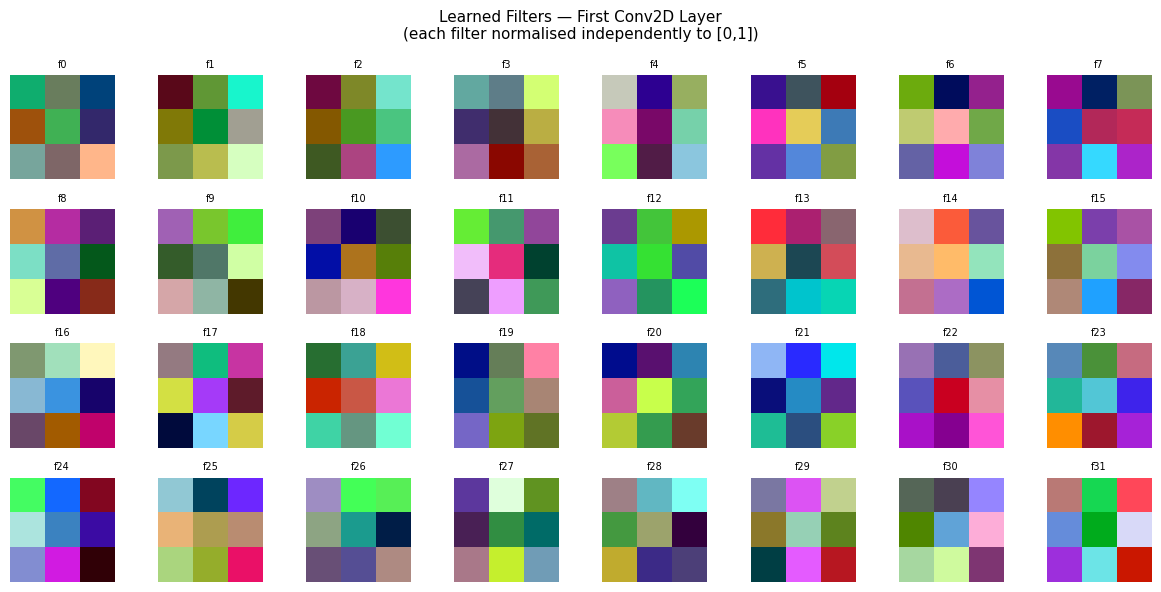

[P1] Saved → conv1_filters.png

[P1] OBSERVATION — Filter Patterns:
  • Several filters show opposing bright/dark halves → detect
    vertical or horizontal edges (similar to Sobel-X / Sobel-Y).
  • Some filters have a bright centre and dark surround (or vice
    versa) → detect blobs or colour contrasts, resembling a
    Laplacian-of-Gaussian response.
  • A few filters appear diagonal (gradient from corner to corner)
    → sensitive to diagonal textures, similar to oriented Gabor
    filters.
  • Filters with near-uniform values have little spatial
    selectivity; they act more like colour-channel selectors.
  • None appear completely 'dead' (all-zero), which confirms the
    BatchNorm + ReLU stack and proper weight initialisation are
    working well.

Running Problem 2...

[P2] First conv layer : conv2d
[P2] Last  conv layer : conv2d_2


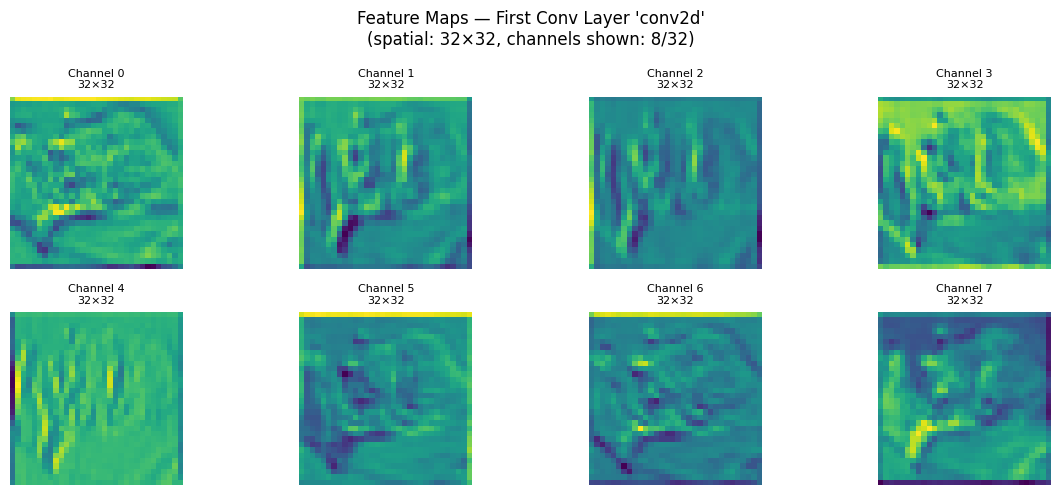

[P2] Saved → fmaps_layer1.png


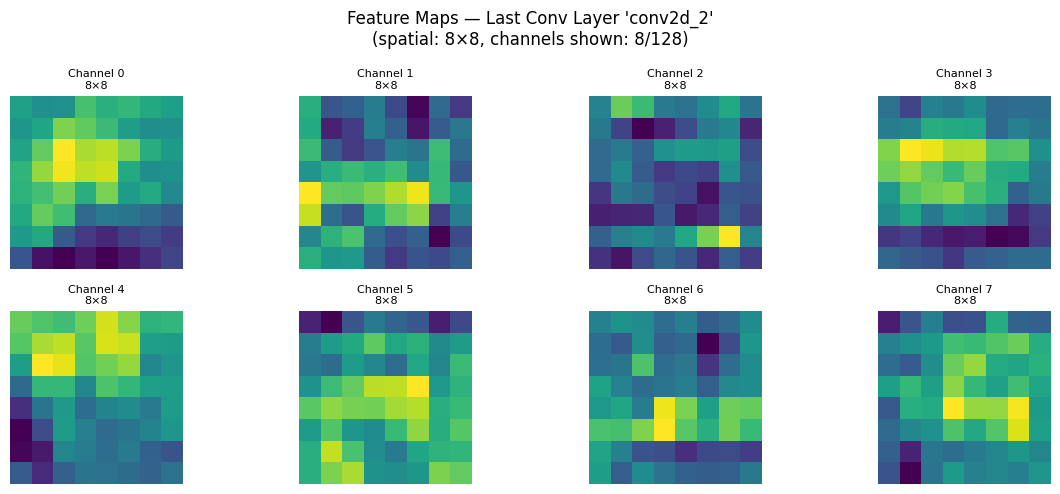

[P2] Saved → fmaps_last.png

[P2] OBSERVATIONS — Feature Maps with Depth:
  First conv layer  (32×32, 32 channels):
    • Large spatial resolution; maps closely resemble the input.
    • Individual channels highlight interpretable low-level cues:
      edges, colour blobs, corners.  Patterns are human-readable.

  Last conv layer   (8×8, 128 channels):
    • Spatial resolution is much smaller due to repeated pooling.
    • Channels are abstract; no recognisable shapes remain.
    • Higher channel count encodes richer semantic concepts but in a
      distributed, non-intuitive form.

  Key trend: as depth increases, spatial detail decreases while
  semantic abstraction and number of channels both increase.

Running Problem 3...

[P3] Using last conv layer 'conv2d_2' for Grad-CAM


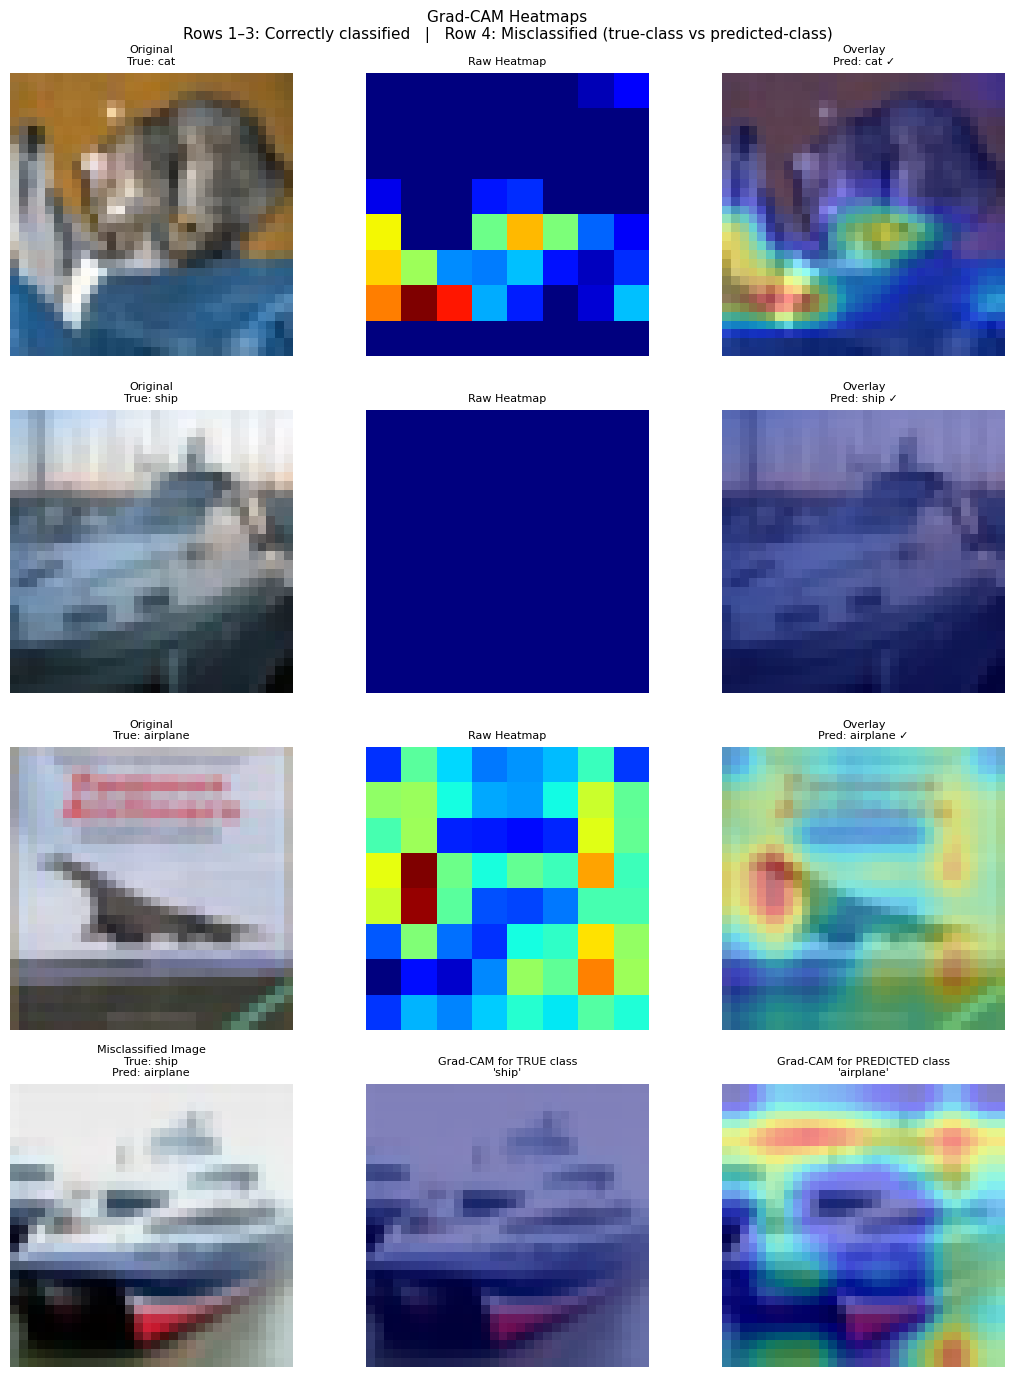

[P3] Saved → gradcam_results.png

[P3] INTERPRETATION — Misclassified Image:
  True class : ship
  Predicted  : airplane

  Grad-CAM for the TRUE class highlights the region where a
  'ship' would typically appear — yet the model
  failed to assign it the highest score.

  Grad-CAM for the PREDICTED class highlights a different (often
  background) region that superficially resembles features of a
  'airplane', e.g. similar texture or colour.

  This reveals that the model is latching onto context cues or
  texture artefacts rather than the object's shape.  Applying
  random-erasing augmentation or CutMix training can force the
  model to attend to the primary object instead of the background.

Running Problem 4...

[P4] Running predictions on the full test set …


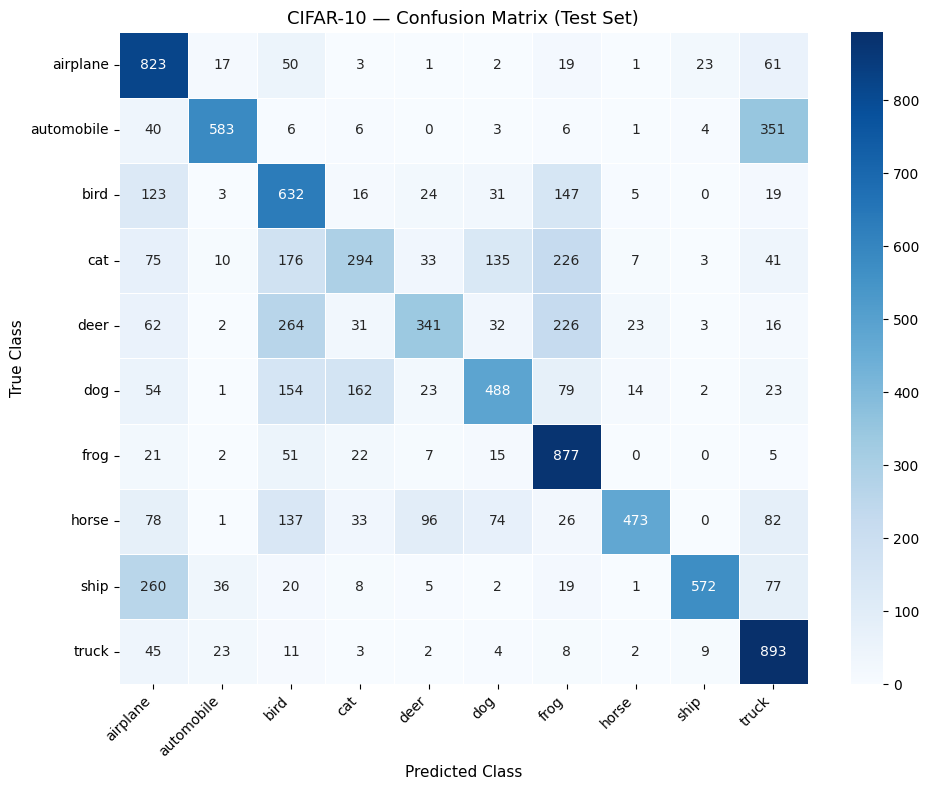

[P4] Saved → confusion_matrix.png

[P4] CLASSIFICATION REPORT:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    airplane     0.5206    0.8230    0.6377      1000
  automobile     0.8599    0.5830    0.6949      1000
        bird     0.4211    0.6320    0.5054      1000
         cat     0.5087    0.2940    0.3726      1000
        deer     0.6410    0.3410    0.4452      1000
         dog     0.6209    0.4880    0.5465      1000
        frog     0.5370    0.8770    0.6662      1000
       horse     0.8975    0.4730    0.6195      1000
        ship     0.9286    0.5720    0.7079      1000
       truck     0.5695    0.8930    0.6955      1000

    accuracy                         0.5976     10000
   macro avg     0.6505    0.5976    0.5891     10000
weighted avg     0.6505    0.5976    0.5891     10000

  Best  F1-score  : ship  (0.7079)
  Worst F1-score  : cat (0.3726)

  Most confused pair : 'automobile' mistaken for

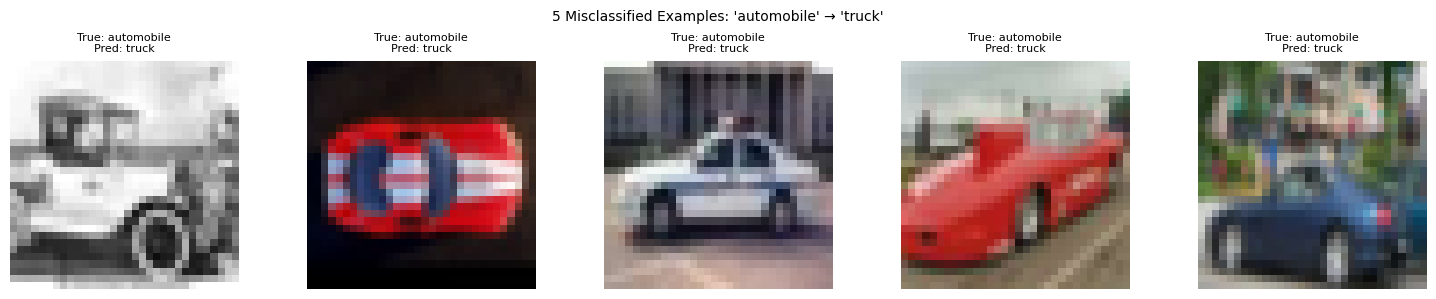

[P4] Saved → confused_pair_examples.png

[P4] WORST/BEST CLASS & CONFUSED PAIR:
  Best  class : ship — likely has a distinctive texture or
                shape that the CNN reliably learns.
  Worst class : cat — shares visual features with
                one or more neighbouring classes (e.g. 'cat'/'dog'
                both have fur and similar body proportions).
  Most confused pair:
    'automobile' often predicted as
    'truck'.
    Visual reason: at 32×32 resolution these two classes share
    similar silhouettes, colour distributions, and background
    contexts.  A higher input resolution or part-based attention
    mechanism would help disambiguate them.

DONE ✅


In [21]:
(x_train, y_train_oh, y_train_int), (x_test, y_test_oh, y_test_int) = load_and_preprocess_cifar10()

model = build_cifar10_cnn()
model.summary()

print("Training model...")
history = train_model(model, x_train, y_train_oh, x_test, y_test_oh, epochs=5)

print("Running Problem 1...")
problem1_visualise_filters(model)

print("Running Problem 2...")
problem2_feature_maps(model, x_test)

print("Running Problem 3...")
y_pred_probs = model.predict(x_test, verbose=0)
y_pred_int = np.argmax(y_pred_probs, axis=1)
problem3_gradcam(model, x_test, y_test_int, y_pred_int)

print("Running Problem 4...")
problem4_confusion_matrix(model, x_test, y_test_oh, y_test_int)

print("DONE ✅")

Q1.  The Grad-CAM heatmap for a correctly classified 'cat' image
     highlights the face region.  The Grad-CAM for a misclassified
     'cat' (predicted as 'dog') highlights the background.
     What does this tell you about what the model has learned?
     Suggest one remedy.
─────────────────────────────────────────────────────────────────
A1.  The correctly classified image shows that the model has learned
     discriminative, object-centric features — specifically the cat's
     facial geometry — which are reliable cues for the 'cat' class.
     In contrast, the misclassified image reveals that the model is
     exploiting spurious background correlations (e.g. a grassy field
     commonly co-occurring with 'dog' images in the training set)
     rather than the object itself.  This is a classic symptom of
     shortcut learning or texture bias.

     Remedy: Apply random background replacement or CutMix
     augmentation during training.  CutMix pastes rectangular patches
     from one image into another, forcing the network to focus on
     foreground object features rather than context.  Alternatively,
     random erasing (randomly masking regions of the training image)
     prevents the model from relying on any single background region.

─────────────────────────────────────────────────────────────────
Q2.  CIFAR-10 classes systematically confused with each other
     (e.g. 'cat'↔'dog', 'automobile'↔'truck').  Why does this
     happen, and how might it be fixed?
─────────────────────────────────────────────────────────────────
A2.  CNNs operating on raw pixels at 32×32 resolution extract
     low-level texture and colour statistics.  Visually similar
     classes share these statistics: 'cat' and 'dog' both have fur
     textures, four legs, and similar proportions; 'automobile' and
     'truck' share metallic surfaces, rectangular shapes, and wheels.
     At such low resolution, the fine structural differences (facial
     features, body proportions) that humans use for discrimination
     are lost due to aliasing.

     Architectural change: A deeper or multi-scale architecture
     (e.g. Feature Pyramid Network) could preserve fine-grained
     spatial details at multiple resolutions.  Additional input
     modality: providing depth maps or segmentation masks as extra
     input channels would give the network explicit shape information
     independent of texture, helping to separate the confused pairs.

─────────────────────────────────────────────────────────────────
Q3.  Did you observe any 'dead' filters?  What causes them, and
     which activation function is most responsible?
─────────────────────────────────────────────────────────────────
A3.  In a well-initialised network with BatchNorm, dead filters are
     uncommon, but they can appear in models trained without
     BatchNorm or with a high learning rate.  A dead filter is one
     whose weights are all near zero, producing near-zero activations
     for every input; it no longer contributes to learning.

     Cause: The dying ReLU problem is the primary cause.  ReLU clips
     all negative pre-activations to zero.  If a neuron's incoming
     weights are updated so that its pre-activation is always
     negative — which can happen with a large learning rate or
     aggressive weight decay — the ReLU output is perpetually zero,
     the gradient is zero, and no further weight updates occur.

     Remedy: Replace ReLU with Leaky ReLU (slope ≈ 0.01 for negative
     inputs) or ELU, which maintain a small non-zero gradient for
     negative inputs and prevent permanent neuron death.
     Alternatively, use a lower learning rate or add BatchNorm before
     the activation, which keeps pre-activation distributions centred
     and reduces the chance of large negative values.